# HYGO - Comprehensive Analysis Report

This notebook provides a comprehensive analysis of AI-generated image error detection results.

All analysis logic is contained in `report_script.py` for easy reuse and testing.

## What This Report Covers:
1. **Vision Model Pricing** - Cost analysis of OpenRouter vision models  
2. **Database Analysis** - Summary of detection results from the database
3. **Image Comparisons** - Visual side-by-side comparisons of original and annotated images
4. **Cost-Benefit Analysis** - Which models provide best value for error detection
5. **Dataset Distribution** - Error patterns across correct vs faulty images

---

## Setup: Import Analysis Functions

Import all required libraries and functions from the report script module.

In [98]:
# Import the report script module
from report_script import *

# Enable inline plotting for Jupyter
%matplotlib inline

print("✅ All analysis functions imported successfully!")
print("\nAvailable functions:")
print("  - setup_environment() - Initialize config and database")
print("  - fetch_vision_models() - Get model pricing from OpenRouter") 
print("  - get_database_summary() - Get database statistics")
print("  - get_model_performance() - Compare model performance")
print("  - plot_cell_heatmap() - Visualize error distribution")
print("  - create_cost_benefit_analysis() - Analyze cost vs performance")
print("  - run_full_analysis() - Run complete analysis pipeline")
print("  ...and more!")

✅ All analysis functions imported successfully!

Available functions:
  - setup_environment() - Initialize config and database
  - fetch_vision_models() - Get model pricing from OpenRouter
  - get_database_summary() - Get database statistics
  - get_model_performance() - Compare model performance
  - plot_cell_heatmap() - Visualize error distribution
  - create_cost_benefit_analysis() - Analyze cost vs performance
  - run_full_analysis() - Run complete analysis pipeline
  ...and more!


---
## Initialize Environment

Load configuration from `.env` file and connect to the database.

In [99]:
# Initialize the analysis environment
config, db_service, env_candidate = setup_environment()

print("\n" + "="*60)
print("ENVIRONMENT INITIALIZED")
print("="*60)
print(f"Config loaded: {bool(config.get('api_key'))}")
print(f"Database ready: {db_service is not None}")
print(f"Model configured: {config.get('model', 'Not set')}")

✅ Configuration loaded from: C:\Users\maste\OneDrive\Desktop\All-Desktop-Files\coding\interview\HYGO\.env
✅ Database initialized: C:\Users\maste\OneDrive\Desktop\All-Desktop-Files\coding\interview\HYGO\hygo_results.db
✅ OpenRouter API key found

ENVIRONMENT INITIALIZED
Config loaded: True
Database ready: True
Model configured: openai/gpt-5-image-mini


---
# Part 1: Vision Model Pricing Analysis

This section queries OpenRouter's API to get all vision-capable models and their pricing.
We'll analyze:
- How many vision models are available
- Their pricing for image processing
- Cost per token for prompt and completion
- Context window sizes

Models are sorted by **image price** (cheapest first) to help with cost-effective model selection.

In [100]:
# Fetch all vision models with pricing information
df_models = fetch_vision_models(config, env_candidate)

if not df_models.empty:
    print(f"\n📊 Loaded {len(df_models)} vision models")
    print(f"Price range: ${df_models['image_price'].min():.10f} to ${df_models['image_price'].max():.10f}")
else:
    print("⚠️ No model pricing data available")

Fetching vision model pricing from OpenRouter...
✅ Found 113 vision-capable models
Price range: $0.0000000000 - $0.2167500000 per image

Pricing Statistics:
       image_price  prompt_price  completion_price
count   113.000000  1.130000e+02      1.130000e+02
mean      0.003968  3.269257e-06      1.413597e-05
std       0.020791  1.444093e-05      5.869770e-05
min       0.000000  0.000000e+00      0.000000e+00
25%       0.000000  1.000000e-07      4.000000e-07
50%       0.000000  3.500000e-07      2.000000e-06
75%       0.001238  2.000000e-06      1.000000e-05
max       0.216750  1.500000e-04      6.000000e-04

📊 Loaded 113 vision models
Price range: $0.0000000000 to $0.2167500000


## Top 10 Most Cost-Effective Vision Models

These are the cheapest models for image processing, sorted by image price.
This table helps identify budget-friendly options for batch processing.

In [101]:
# Display top 10 cheapest models
top_10 = df_models.head(10).copy()
top_10['image_price_formatted'] = top_10['image_price'].apply(lambda x: f"${x:.10f}")
top_10['prompt_price_formatted'] = top_10['prompt_price'].apply(lambda x: f"${x:.12f}")
top_10['completion_price_formatted'] = top_10['completion_price'].apply(lambda x: f"${x:.12f}")

display_df = top_10[['id', 'name', 'image_price_formatted', 'prompt_price_formatted', 
                      'completion_price_formatted', 'context_length']].copy()
display_df.columns = ['Model ID', 'Name', 'Image Price', 'Prompt Price/Token', 
                      'Completion Price/Token', 'Context Length']

display(display_df)

,Model ID,Name,Image Price,Prompt Price/Token,Completion Price/Token,Context Length
0,openrouter/sherlock-dash-alpha,Sherlock Dash Alpha,$0.0000000000,$0.000000000000,$0.000000000000,1840000
1,openrouter/sherlock-think-alpha,Sherlock Think Alpha,$0.0000000000,$0.000000000000,$0.000000000000,1840000
2,nvidia/nemotron-nano-12b-v2-vl:free,NVIDIA: Nemotron Nano 12B 2 VL (free),$0.0000000000,$0.000000000000,$0.000000000000,128000
3,mistralai/mistral-small-3.2-24b-instruct:free,Mistral: Mistral Small 3.2 24B (free),$0.0000000000,$0.000000000000,$0.000000000000,131072
4,qwen/qwen2.5-vl-32b-instruct:free,Qwen: Qwen2.5 VL 32B Instruct (free),$0.0000000000,$0.000000000000,$0.000000000000,16384
5,mistralai/mistral-small-3.1-24b-instruct:free,Mistral: Mistral Small 3.1 24B (free),$0.0000000000,$0.000000000000,$0.000000000000,96000
6,google/gemma-3-4b-it:free,Google: Gemma 3 4B (free),$0.0000000000,$0.000000000000,$0.000000000000,32768
7,google/gemma-3-12b-it:free,Google: Gemma 3 12B (free),$0.0000000000,$0.000000000000,$0.000000000000,32768
8,google/gemma-3-27b-it:free,Google: Gemma 3 27B (free),$0.0000000000,$0.000000000000,$0.000000000000,131072
9,google/gemini-2.0-flash-exp:free,Google: Gemini 2.0 Flash Experimental (free),$0.0000000000,$0.000000000000,$0.000000000000,1048576


## Pricing Visualization: Image Cost Distribution

This chart shows the distribution of image processing costs across all vision models.
The log scale helps visualize the wide range of pricing tiers.

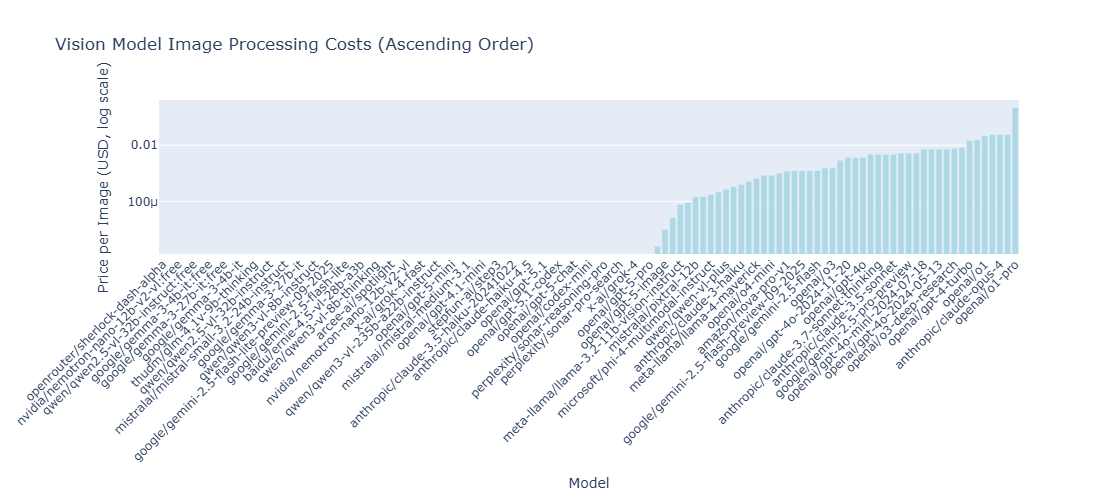

In [102]:
# Create pricing visualization
fig = go.Figure()

# Add bar chart for image prices
fig.add_trace(go.Bar(
    x=df_models['id'],
    y=df_models['image_price'],
    name='Image Price',
    marker_color='lightblue',
    hovertemplate='<b>%{x}</b><br>Image: $%{y:.10f}<extra></extra>'
))

fig.update_layout(
    title='Vision Model Image Processing Costs (Ascending Order)',
    xaxis_title='Model',
    yaxis_title='Price per Image (USD, log scale)',
    yaxis_type='log',
    height=500,
    showlegend=False,
    xaxis={'tickangle': -45}
)

fig.show()

## Cost Comparison: Top 20 Models

Detailed comparison of image, prompt, and completion costs for the most cost-effective models.

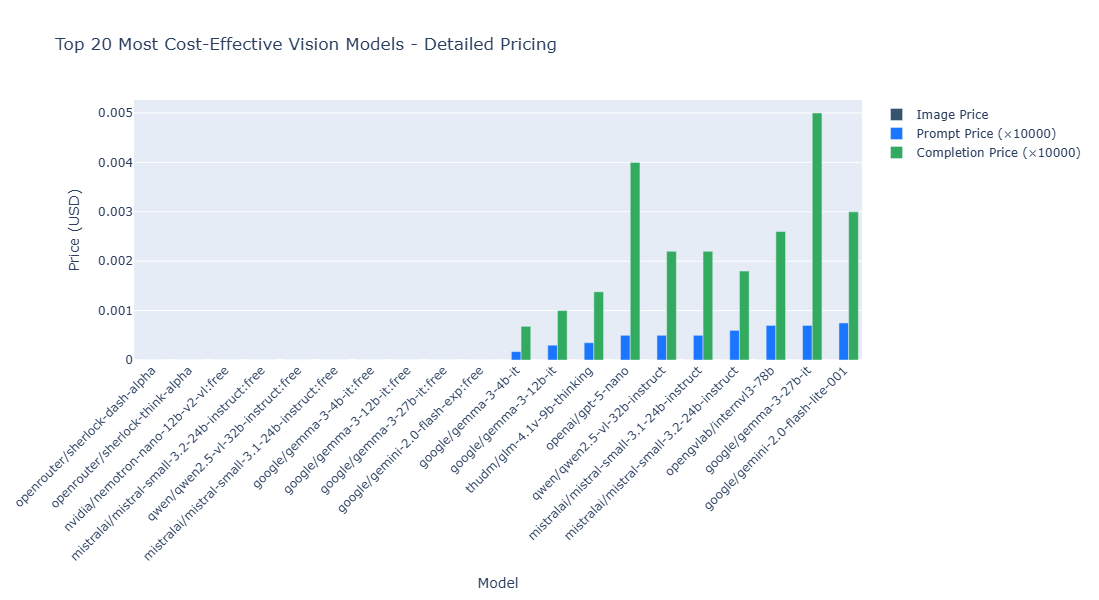

In [103]:
# Create grouped bar chart for top 20 models
top_20 = df_models.head(20)

fig = go.Figure()

fig.add_trace(go.Bar(
    name='Image Price',
    x=top_20['id'],
    y=top_20['image_price'],
    marker_color='rgb(55, 83, 109)'
))

fig.add_trace(go.Bar(
    name='Prompt Price (×10000)',
    x=top_20['id'],
    y=top_20['prompt_price'] * 10000,
    marker_color='rgb(26, 118, 255)'
))

fig.add_trace(go.Bar(
    name='Completion Price (×10000)',
    x=top_20['id'],
    y=top_20['completion_price'] * 10000,
    marker_color='rgb(50, 171, 96)'
))

fig.update_layout(
    title='Top 20 Most Cost-Effective Vision Models - Detailed Pricing',
    xaxis_title='Model',
    yaxis_title='Price (USD)',
    barmode='group',
    height=600,
    xaxis={'tickangle': -45}
)

fig.show()

---
# Part 2: Database Analysis Results

Query the HYGO database to get analysis results from previous model runs.
This includes:
- Overall summary statistics
- Model comparison metrics
- Error detection patterns

In [104]:
# Import database models for queries
from sqlalchemy import func
from src.database import Dataset, OriginalImage, ModelTest, ImageAnalysis, CellResult

session = db_service.Session()

# Get overall statistics
num_datasets = session.query(func.count(Dataset.id)).scalar()
num_images = session.query(func.count(OriginalImage.id)).scalar()
num_model_tests = session.query(func.count(ModelTest.id)).scalar()
num_analyses = session.query(func.count(ImageAnalysis.id)).scalar()

print("="*60)
print("DATABASE SUMMARY")
print("="*60)
print(f"Total Datasets:      {num_datasets}")
print(f"Total Images:        {num_images}")
print(f"Model Tests Run:     {num_model_tests}")
print(f"Total Analyses:      {num_analyses}")

# Get average issues per image
avg_issues = session.query(func.avg(ImageAnalysis.total_issues)).scalar()
print(f"\nAverage Issues per Image: {avg_issues:.2f}" if avg_issues else "\nNo analyses found")

session.close()

DATABASE SUMMARY
Total Datasets:      2
Total Images:        14
Model Tests Run:     5
Total Analyses:      63

Average Issues per Image: 1.54


## Model Performance Comparison

Compare how different models performed in detecting errors.
Shows average issues detected, min/max values, and number of images analyzed.

In [105]:
session = db_service.Session()

# Query model performance
model_stats = session.query(
    ModelTest.model_name,
    func.count(ImageAnalysis.id).label('num_images'),
    func.avg(ImageAnalysis.total_issues).label('avg_issues'),
    func.min(ImageAnalysis.total_issues).label('min_issues'),
    func.max(ImageAnalysis.total_issues).label('max_issues')
).join(ImageAnalysis).group_by(ModelTest.model_name).all()

if model_stats:
    df_model_perf = pd.DataFrame(model_stats, columns=[
        'Model', 'Images Analyzed', 'Avg Issues', 'Min Issues', 'Max Issues'
    ])
    df_model_perf = df_model_perf.sort_values('Avg Issues')
    
    print("\n" + "="*60)
    print("MODEL PERFORMANCE COMPARISON")
    print("="*60)
    display(df_model_perf)
else:
    print("\nNo model performance data available yet.")
    df_model_perf = pd.DataFrame()

session.close()


MODEL PERFORMANCE COMPARISON


,Model,Images Analyzed,Avg Issues,Min Issues,Max Issues
1,openai/gpt-5-image,14,1.428571,0,5
0,openai/gpt-4o-mini,35,1.542857,0,7
2,openai/gpt-5-image-mini,14,1.642857,0,7


## Error Detection Heatmap (3x3 Grid)

Shows which cells in the 3x3 grid have the most detected errors across all analyses.
Helps identify if certain areas of images are more prone to AI generation errors.

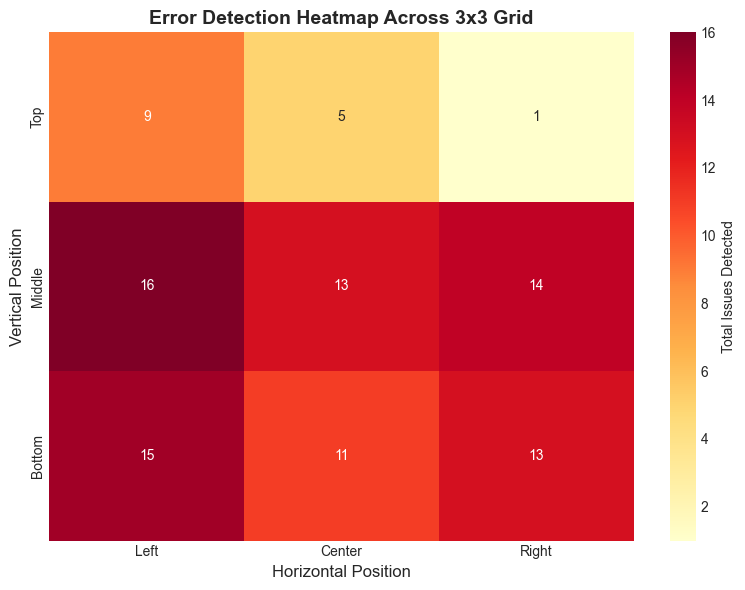

In [106]:
session = db_service.Session()

# Query cell-level error counts
cell_stats = session.query(
    CellResult.row,
    CellResult.col,
    func.sum(CellResult.issue_count).label('total_issues')
).group_by(CellResult.row, CellResult.col).all()

session.close()

if cell_stats:
    # Create 3x3 heatmap matrix
    heatmap_data = np.zeros((3, 3))
    for row, col, issues in cell_stats:
        heatmap_data[row][col] = issues
    
    # Plot heatmap
    plt.figure(figsize=(8, 6))
    sns.heatmap(heatmap_data, annot=True, fmt='.0f', cmap='YlOrRd', 
                cbar_kws={'label': 'Total Issues Detected'},
                xticklabels=['Left', 'Center', 'Right'],
                yticklabels=['Top', 'Middle', 'Bottom'])
    plt.title('Error Detection Heatmap Across 3x3 Grid', fontsize=14, fontweight='bold')
    plt.xlabel('Horizontal Position', fontsize=12)
    plt.ylabel('Vertical Position', fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print("No cell-level data available for heatmap.")

---
# Part 3: Image Comparison Showcase

Display side-by-side comparisons of:
1. Original (raw) images
2. Annotated output images with error markers
3. Detected errors listed below each image

For multi-model comparisons, show results from different models side-by-side.

In [107]:
# Helper function to display image with error details
def display_image_analysis(image_filename, model_name):
    """
    Display original and annotated image with error details.
    
    Args:
        image_filename: Name of the image file
        model_name: Name of the model used for analysis
    """
    result = db_service.get_model_image_issues(model_name, image_filename)
    
    if not result:
        print(f"No results found for {image_filename} with {model_name}")
        return None
    
    return result

# Helper function to create comparison figure
def create_comparison_figure(results_list, image_filename):
    """
    Create side-by-side comparison of multiple model results.
    
    Args:
        results_list: List of result dictionaries from different models
        image_filename: Name of the image being compared
    """
    num_models = len(results_list)
    
    fig, axes = plt.subplots(2, num_models, figsize=(6*num_models, 10))
    if num_models == 1:
        axes = axes.reshape(2, 1)
    
    for idx, result in enumerate(results_list):
        # Load images
        raw_path = Path(result['raw_image_path'])
        annotated_path = Path(result['annotated_image_path'])
        
        if raw_path.exists():
            raw_img = Image.open(raw_path)
            axes[0, idx].imshow(raw_img)
            axes[0, idx].set_title(f"Original Image\n{result['model_name']}", 
                                   fontweight='bold', fontsize=10)
            axes[0, idx].axis('off')
        
        if annotated_path.exists():
            annotated_img = Image.open(annotated_path)
            axes[1, idx].imshow(annotated_img)
            axes[1, idx].set_title(f"Annotated ({result['total_issues']} issues)\n{result['model_name']}", 
                                   fontweight='bold', fontsize=10)
            axes[1, idx].axis('off')
    
    plt.suptitle(f"Image Comparison: {image_filename}", fontsize=14, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()
    
    # Display error details for each model
    for result in results_list:
        print(f"\n{'='*80}")
        print(f"Model: {result['model_name']}")
        print(f"Total Issues: {result['total_issues']}")
        print(f"{'='*80}")
        
        if result['all_issues']:
            for i, issue in enumerate(result['all_issues'], 1):
                print(f"{i}. {issue}")
        else:
            print("No issues detected.")

print("✅ Image comparison functions defined")

✅ Image comparison functions defined


## Get Available Images and Models

Query the database to see what images and models are available for comparison.

In [108]:
session = db_service.Session()

# Get all analyzed images with their models
image_model_pairs = session.query(
    OriginalImage.filename,
    ModelTest.model_name
).join(
    ImageAnalysis, OriginalImage.id == ImageAnalysis.original_image_id
).join(
    ModelTest, ImageAnalysis.model_test_id == ModelTest.id
).distinct().all()

if image_model_pairs:
    df_available = pd.DataFrame(image_model_pairs, columns=['Image', 'Model'])
    print("\nAvailable Image-Model Combinations:")
    print("="*60)
    display(df_available)
    
    # Get unique images and models
    unique_images = df_available['Image'].unique()
    unique_models = df_available['Model'].unique()
    
    print(f"\nUnique Images: {len(unique_images)}")
    print(f"Unique Models: {len(unique_models)}")
else:
    print("\nNo analyzed images found in database.")
    unique_images = []
    unique_models = []

session.close()


Available Image-Model Combinations:


,Image,Model
0,gibberish-in-ai-generated-image.webp,openai/gpt-4o-mini
1,hand.png,openai/gpt-4o-mini
2,horse-extra-legs.jpg,openai/gpt-4o-mini
3,many-faulty-elements.webp,openai/gpt-4o-mini
4,multiple-arms.png,openai/gpt-4o-mini
5,warped-building-unnatural-artifact.webp,openai/gpt-4o-mini
6,weird-car-design.jpeg,openai/gpt-4o-mini
7,3d-rendered-photos-super-car-side-angle-view-p...,openai/gpt-4o-mini
8,friendly-happy-dog-running-fast-pace-side-view...,openai/gpt-4o-mini
9,full-body-pic.jpg,openai/gpt-4o-mini



Unique Images: 14
Unique Models: 3


## Example: Single Model Image Analysis

Display detailed analysis for one image with one model.
Change the image_filename and model_name variables to view different results.

Displaying analysis for: gibberish-in-ai-generated-image.webp
Model: openai/gpt-5-image



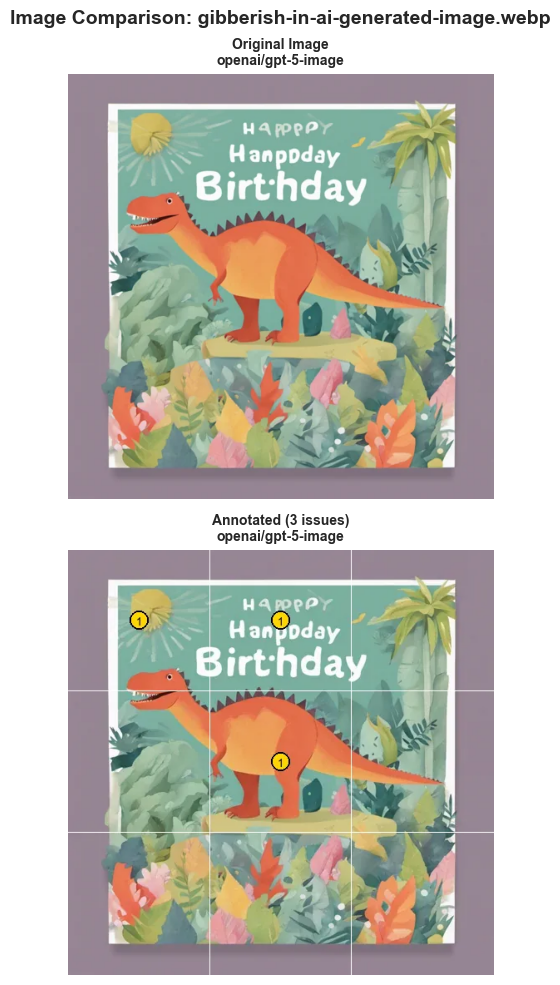


Model: openai/gpt-5-image
Total Issues: 3
1. Sun appears to have an unrealistic shape with no clear definition of rays.
2. Nonsensical text: 'Hanpdday' is a misspelling of 'Birthday'.
3. The dinosaur's right arm appears disproportionately short compared to its body.


In [109]:
# Customize these values to view different results
if len(unique_images) > 0 and len(unique_models) > 0:
    example_image = unique_images[0]
    example_model = unique_models[1]
    
    print(f"Displaying analysis for: {example_image}")
    print(f"Model: {example_model}\n")
    
    result = display_image_analysis(example_image, example_model)
    
    if result:
        create_comparison_figure([result], example_image)
else:
    print("No data available for display. Run the main analysis pipeline first.")

## Example: Multi-Model Comparison

Compare how different models analyzed the same image.
Shows differences in error detection between models.

Comparing models on Correct: 3d-rendered-photos-super-car-side-angle-view-parked-side-road.avif
Models: openai/gpt-4o-mini, openai/gpt-5-image, openai/gpt-5-image-mini



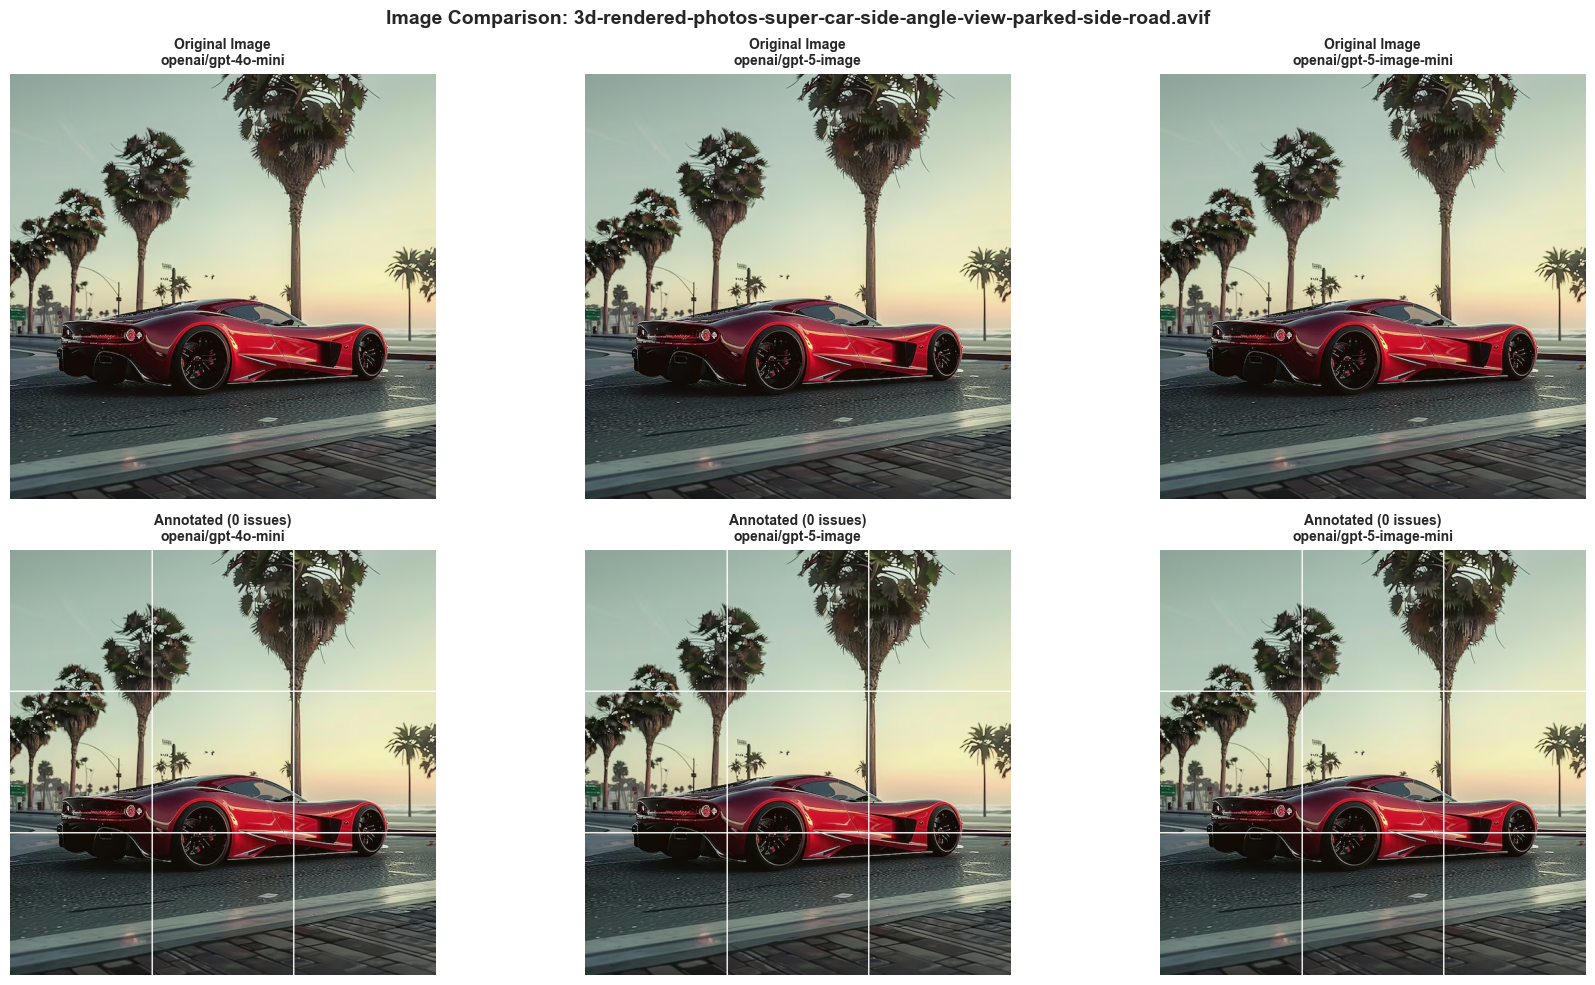


Model: openai/gpt-4o-mini
Total Issues: 0
No issues detected.

Model: openai/gpt-5-image
Total Issues: 0
No issues detected.

Model: openai/gpt-5-image-mini
Total Issues: 0
No issues detected.
Comparing models on Faulty: gibberish-in-ai-generated-image.webp
Models: openai/gpt-4o-mini, openai/gpt-5-image, openai/gpt-5-image-mini



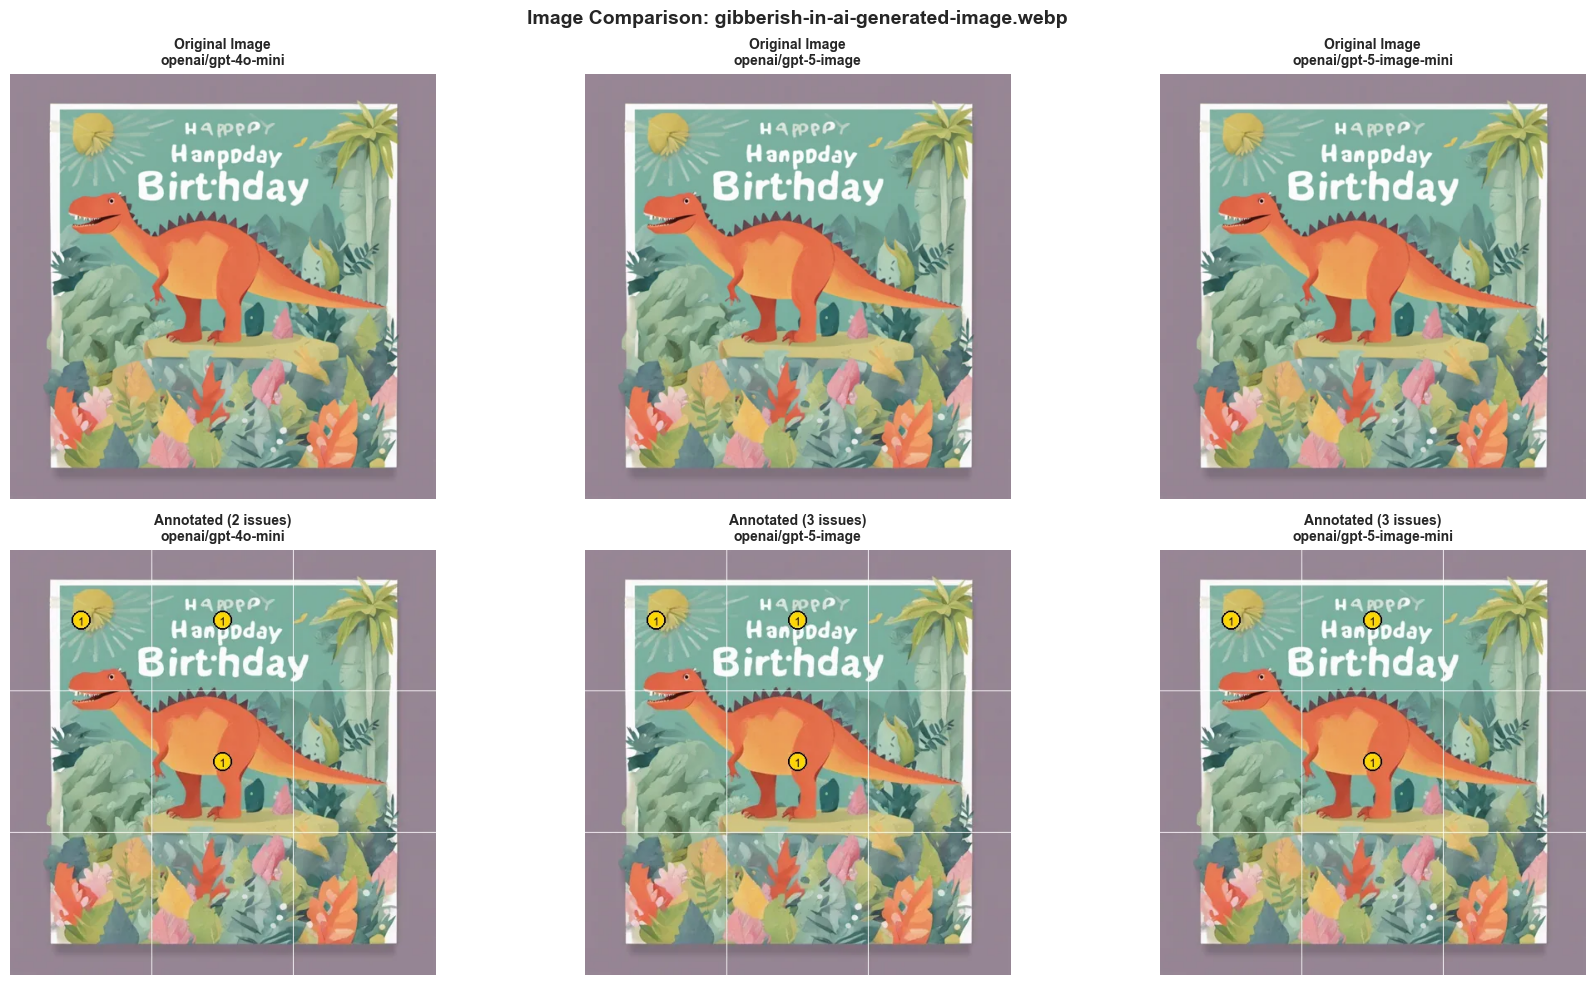


Model: openai/gpt-4o-mini
Total Issues: 2
1. Yellow sun shape appears distorted and unnatural.
2. Nonsensical text: 'Hanpdday' is a misspelling.

Model: openai/gpt-5-image
Total Issues: 3
1. Sun appears to have an unrealistic shape with no clear definition of rays.
2. Nonsensical text: 'Hanpdday' is a misspelling of 'Birthday'.
3. The dinosaur's right arm appears disproportionately short compared to its body.

Model: openai/gpt-5-image-mini
Total Issues: 3
1. The sun appears as a crumpled ball, which is a nonsensical geometric representation.
2. Nonsensical or unreadable text: 'Hanpdday' instead of 'Birthday'
3. Distorted front limb anatomy


In [115]:
# Compare multiple models on the same image
# Extended to show 1 example from 'correct' and 1 from 'faulty' when possible
if len(unique_images) > 0 and len(unique_models) >= 2:
    session = db_service.Session()

    # Helper function to find an image analyzed by >= 2 distinct models in a category
    def find_multi_model_image_for_category(category: str):
        q = (
            session.query(
                OriginalImage.filename,
                func.count(func.distinct(ModelTest.model_name)).label('model_count')
            )
            .join(Dataset, OriginalImage.dataset_id == Dataset.id)
            .join(ImageAnalysis, OriginalImage.id == ImageAnalysis.original_image_id)
            .join(ModelTest, ImageAnalysis.model_test_id == ModelTest.id)
            .filter(Dataset.category == category)
            .group_by(OriginalImage.filename)
            .having(func.count(func.distinct(ModelTest.model_name)) >= 2)
        )
        return q.first()

    # Find a correct image analyzed by multiple models
    correct_multi = find_multi_model_image_for_category('correct')

    # Find a faulty image analyzed by multiple models
    faulty_multi = find_multi_model_image_for_category('faulty')

    # Fallback - any image analyzed by multiple models
    any_multi_query = (
        session.query(
            OriginalImage.filename,
            func.count(func.distinct(ModelTest.model_name)).label('model_count')
        )
        .join(ImageAnalysis, OriginalImage.id == ImageAnalysis.original_image_id)
        .join(ModelTest, ImageAnalysis.model_test_id == ModelTest.id)
        .group_by(OriginalImage.filename)
        .having(func.count(func.distinct(ModelTest.model_name)) >= 2)
    )
    any_multi = any_multi_query.first()

    session.close()

    shown = 0

    def show_comparison_for(image_name, category_label=None):
        models_for_image = df_available[df_available['Image'] == image_name]['Model'].tolist()
        if not models_for_image:
            return False
        print(f"Comparing models on{(' ' + category_label) if category_label else ''}: {image_name}")
        print(f"Models: {', '.join(models_for_image)}\n")
        results = []
        for model in models_for_image[:3]:  # Limit to 3 models for display
            result = display_image_analysis(image_name, model)
            if result:
                results.append(result)
        if results:
            create_comparison_figure(results, image_name)
            return True
        return False

    # Show one correct example (if available)
    if correct_multi:
        if show_comparison_for(correct_multi[0], 'Correct'):
            shown += 1

    # Show one faulty example (if available)
    if faulty_multi:
        if show_comparison_for(faulty_multi[0], 'Faulty'):
            shown += 1

    # Fallback: If nothing shown, use any multi-model image
    if shown == 0 and any_multi:
        if show_comparison_for(any_multi[0]):
            shown += 1

    if shown == 0:
        print("No images analyzed by multiple models found.")
else:
    print("Insufficient data for multi-model comparison.")

---
# Part 4: Cost-Benefit Analysis

Combine pricing data with model performance to determine the best value models.
Compares:
- Detection accuracy (average issues found)
- Cost per image
- Cost per detected issue


COST-BENEFIT ANALYSIS

Models ranked by cost-effectiveness (cost per detected issue):



,Model,Images Analyzed,Avg Issues,Min Issues,Max Issues,Image Price,Cost per Issue
2,openai/gpt-5-image-mini,14,1.642857,0,7,$0.0000025000,$0.0000015217
1,openai/gpt-5-image,14,1.428571,0,5,$0.0000100000,$0.0000070000
0,openai/gpt-4o-mini,35,1.542857,0,7,$0.0002170000,$0.0001406481


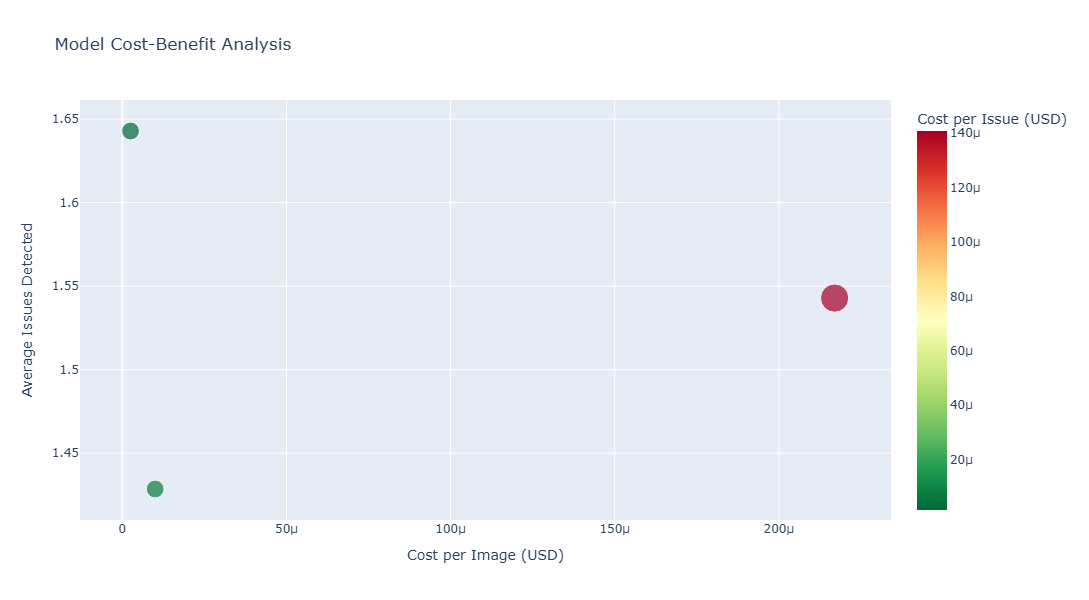

In [111]:
# Merge performance and pricing data
if not df_model_perf.empty and not df_models.empty:
    # Create cost-benefit analysis
    cost_benefit = df_model_perf.copy()
    
    # Add pricing information - get once per model to avoid duplicate API calls
    def get_price_safe(model_name):
        pricing = get_model_pricing(model_name, use_user_filter=False, env_path=str(env_candidate))
        return pricing['image_price'] if pricing else 0
    
    cost_benefit['Image Price'] = cost_benefit['Model'].apply(get_price_safe)
    
    # Calculate cost per detected issue
    cost_benefit['Cost per Issue'] = cost_benefit.apply(
        lambda row: row['Image Price'] / row['Avg Issues'] if row['Avg Issues'] > 0 else float('inf'),
        axis=1
    )
    
    # Sort by cost per issue (lower is better)
    cost_benefit = cost_benefit.sort_values('Cost per Issue')
    
    print("\n" + "="*80)
    print("COST-BENEFIT ANALYSIS")
    print("="*80)
    print("\nModels ranked by cost-effectiveness (cost per detected issue):\n")
    
    display_cb = cost_benefit.copy()
    display_cb['Image Price'] = display_cb['Image Price'].apply(lambda x: f"${x:.10f}")
    display_cb['Cost per Issue'] = display_cb['Cost per Issue'].apply(
        lambda x: f"${x:.10f}" if x != float('inf') else "N/A"
    )
    display(display_cb)
    
    # Visualize cost-benefit
    fig = px.scatter(
        cost_benefit,
        x='Image Price',
        y='Avg Issues',
        size='Images Analyzed',
        color='Cost per Issue',
        hover_data=['Model'],
        title='Model Cost-Benefit Analysis',
        labels={
            'Image Price': 'Cost per Image (USD)',
            'Avg Issues': 'Average Issues Detected',
            'Cost per Issue': 'Cost per Issue (USD)'
        },
        color_continuous_scale='RdYlGn_r'
    )
    
    fig.update_layout(height=600)
    fig.show()
    
else:
    print("\nInsufficient data for cost-benefit analysis.")
    print("Run analyses with multiple models to enable this section.")

## Model Efficiency Score

Calculate an efficiency score combining:
- Detection rate (higher is better)
- Cost (lower is better)

Score = (Avg Issues Detected) / (Image Price × 10000)

Higher scores indicate better value.

In [112]:
if not df_model_perf.empty and not df_models.empty:
    efficiency = cost_benefit.copy()
    
    # Convert Image Price string back to float for calculation - get once per model to avoid duplicate API calls
    def get_price_numeric_safe(model_name):
        pricing = get_model_pricing(model_name, use_user_filter=False, env_path=str(env_candidate))
        return pricing['image_price'] if pricing else 0
    
    efficiency['Image Price Numeric'] = efficiency['Model'].apply(get_price_numeric_safe)
    
    # Calculate efficiency score
    efficiency['Efficiency Score'] = efficiency.apply(
        lambda row: row['Avg Issues'] / (row['Image Price Numeric'] * 10000) 
        if row['Image Price Numeric'] > 0 else 0,
        axis=1
    )
    
    efficiency = efficiency.sort_values('Efficiency Score', ascending=False)
    
    # Plot efficiency scores
    fig = go.Figure(data=[
        go.Bar(
            x=efficiency['Model'],
            y=efficiency['Efficiency Score'],
            marker_color='lightgreen',
            text=efficiency['Efficiency Score'].round(2),
            textposition='auto'
        )
    ])
    
    fig.update_layout(
        title='Model Efficiency Scores (Higher = Better Value)',
        xaxis_title='Model',
        yaxis_title='Efficiency Score (Issues / Cost)',
        height=500
    )
    
    fig.show()
    
    print("\nTop 5 Most Efficient Models:")
    display(efficiency[['Model', 'Avg Issues', 'Image Price', 'Efficiency Score']].head())
else:
    print("Insufficient data for efficiency analysis.")


Top 5 Most Efficient Models:


,Model,Avg Issues,Image Price,Efficiency Score
2,openai/gpt-5-image-mini,1.642857,0.000003,65.714286
1,openai/gpt-5-image,1.428571,0.000010,14.285714
0,openai/gpt-4o-mini,1.542857,0.000217,0.710994


---
# Part 5: Dataset Distribution Analysis

Analyze the distribution of errors across correct vs. faulty image datasets.
Shows if models can distinguish between intentionally correct and faulty AI-generated images.

In [113]:
session = db_service.Session()

# Query dataset statistics
dataset_stats = session.query(
    Dataset.name,
    Dataset.category,
    func.count(ImageAnalysis.id).label('num_analyses'),
    func.avg(ImageAnalysis.total_issues).label('avg_issues'),
    func.sum(ImageAnalysis.total_issues).label('total_issues')
).join(
    OriginalImage, Dataset.id == OriginalImage.dataset_id
).join(
    ImageAnalysis, OriginalImage.id == ImageAnalysis.original_image_id
).group_by(Dataset.name, Dataset.category).all()

session.close()

if dataset_stats:
    df_datasets = pd.DataFrame(dataset_stats, columns=[
        'Dataset', 'Category', 'Analyses', 'Avg Issues', 'Total Issues'
    ])
    
    print("\n" + "="*60)
    print("DATASET ANALYSIS")
    print("="*60)
    display(df_datasets)
    
    # Create comparison chart
    fig = go.Figure()
    
    fig.add_trace(go.Bar(
        name='Average Issues',
        x=df_datasets['Dataset'],
        y=df_datasets['Avg Issues'],
        marker_color=['green' if cat == 'correct' else 'red' 
                     for cat in df_datasets['Category']]
    ))
    
    fig.update_layout(
        title='Average Issues by Dataset (Green=Correct, Red=Faulty)',
        xaxis_title='Dataset',
        yaxis_title='Average Issues Detected',
        height=400
    )
    
    fig.show()
else:
    print("\nNo dataset statistics available.")


DATASET ANALYSIS


,Dataset,Category,Analyses,Avg Issues,Total Issues
0,correct-ai-images,correct,28,0.285714,8
1,faulty-ai-images,faulty,35,2.542857,89


---
# Report Export Instructions

## Export to PDF

To convert this notebook to a PDF report, use one of these methods:

### Method 1: Command Line (nbconvert)
```bash
jupyter nbconvert --to pdf report.ipynb
```

### Method 2: HTML first, then PDF
If you don't have LaTeX installed:
```bash
# Install webpdf support
pip install nbconvert[webpdf]

# Convert to PDF via HTML
jupyter nbconvert --to webpdf report.ipynb
```

### Method 3: From Jupyter Interface
1. Go to File → Download as → PDF via LaTeX
2. Or install notebook-as-pdf extension: `pip install notebook-as-pdf`
3. Then use File → Download as → PDF

## Export to HTML
```bash
jupyter nbconvert --to html report.ipynb
```

The HTML version includes all interactive plots and can be shared via web browser.

---

## Report Summary

This report provides comprehensive analysis of:

1. **Model Pricing** - All vision models ranked by cost-effectiveness
2. **Performance Metrics** - How well each model detects errors
3. **Visual Comparisons** - Side-by-side image analysis results
4. **Cost-Benefit Analysis** - Best value models for batch processing
5. **Dataset Insights** - Error patterns across image types

### Key Findings:
- Total vision models available: (see Part 1)
- Most cost-effective model: (see Top 10 table)
- Best performing model: (see Model Performance Comparison)
- Recommended model for production: (see Efficiency Score)

### Next Steps:
1. Review cost-benefit analysis to select optimal model
2. Run TEST_ALL mode to compare more models
3. Analyze specific images with multiple models
4. Export this report to PDF for sharing

### Future Improvements

- **Better project hygiene**
  - Add structured logging (e.g., `logging` with per-module loggers) so API failures, model fallbacks, and DB writes are easier to debug and analyze.
  - Replace ad-hoc `pip`/conda setup with **Poetry** for dependency and virtualenv management (lockfile, reproducible builds, extras for CLI vs dev).

- **Richer visualization & analytics**
  - Extend the current 3×3 grid overlay to include additional views: per-cell issue heatmaps over time, per-model comparison plots, and aggregate charts from the SQLite DB (e.g., average issues per model, per dataset, per cell).
  - Generate notebook-ready plots (Matplotlib/Plotly) that summarize total issues, severity distributions, and model performance across many images.

- **Expanded evaluation datasets**
  - Build a curated in-house dataset with paired “correct” vs “faulty” images (as you’re already doing), plus labels for issue type and location to evaluate explanation quality.
  - Augment it with public AI-generated-image benchmarks (e.g., GenImage, AIGI-Holmes) that provide larger-scale fake/real pairs and annotations for common artifacts.

- **Model comparison: cheap vs expensive vs local**
  - Systematically compare the cheapest vision models vs premium ones and vs local models, using the same dataset and metrics stored in the database.
  - Use the OpenRouter pricing and vision-capability table to pick a top-K of the cheapest and most expensive vision models for each experiment.
  - Add support for local multimodal / vision models and benchmark them against OpenRouter models on both accuracy and latency.

- **Hardware-aware optimization for local models**
  - Experiment with quantization (e.g., 4-bit / 8-bit), tensor parallelism, and GPU vs CPU execution to find the best performance-per-dollar configuration for local models.
  - Record inference time, VRAM usage, and throughput alongside detection quality so you can plot cost-vs-quality curves per model/hardware combo.

- **Stronger experimental framework & reporting**
  - Turn the current pipeline into a repeatable benchmark harness: same dataset and grid, but pluggable model backend (OpenRouter model ID or local model tag), with results auto-logged.
  - Review cost-benefit analysis to select the optimal model (cheapest acceptable quality vs best-performing model).
  - Run a `TEST_ALL` mode to compare more models in one sweep and automatically summarize the results.
  - Analyze specific images with multiple models side-by-side to understand qualitative differences in explanations and detections.
  - Export this report (including tables, plots, and selected annotated images) to PDF for sharing with others.

---